파일 구조 알아보기

In [1]:
import pandas as pd
from pathlib import Path

# 1) 최종3.csv 불러오기
csv_path = Path("/Users/mousebook/Documents/university/연구실/solar/generator/v2/source/최종3.csv")
df3 = pd.read_csv(csv_path, encoding="utf-8-sig")

# 2) 컬럼명 출력
print("Columns in 최종3.csv:")
for col in df3.columns:
    print("-", col)


Columns in 최종3.csv:
- 태양광발전시설명
- 소재지도로명주소
- 소재지지번주소
- 위도
- 경도
- 설치상세위치구분명
- 가동상태구분명
- 설비용량
- 공급전압
- 주파수
- 설치연도
- 세부용도
- 허가일자
- 허가기관
- 설치면적
- 데이터기준일자
- x
- y
- region_1depth_name
- region_2depth_name
- region_3depth_h_name
- source_file


### 지도에 지역 그리기

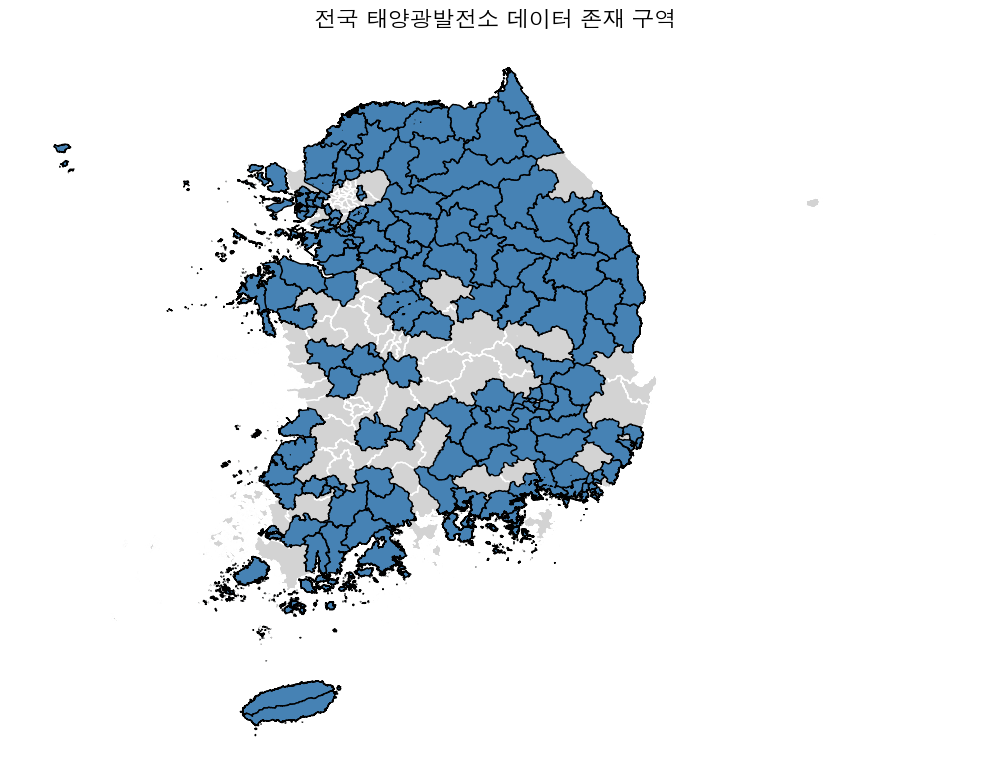

In [14]:
import pandas as pd
import geopandas as gpd
import pickle
import matplotlib.pyplot as plt
from pathlib import Path
from utils import filter_region_and_get_code_and_geom, load_region_pairs

# 1) 한글 폰트 설정 (macOS의 경우 AppleGothic 사용)
plt.rc("font", family="AppleGothic")
plt.rc("axes", unicode_minus=False)

# 2) 전체 경계 GeoDataFrame 불러오기
pkl_path = Path("/Users/mousebook/Documents/university/연구실/solar/generator/v2/source/gdf_dict_v2.pkl")
with open(pkl_path, "rb") as f:
    gdf_dict = pickle.load(f)

gdf_all = gpd.GeoDataFrame(
    pd.concat(gdf_dict.values(), ignore_index=True),
    crs=list(gdf_dict.values())[0].crs
)

# 3) 데이터 존재 지역만 추출
gdf_list = []
for depth1, depth2 in load_region_pairs():
    try:
        _, _, gdf_region = filter_region_and_get_code_and_geom(depth1, depth2)
        gdf_list.append(gdf_region)
    except Exception:
        continue

gdf_present = gpd.GeoDataFrame(
    pd.concat(gdf_list, ignore_index=True),
    crs=gdf_all.crs
)

# 4) 지도 그리기
fig, ax = plt.subplots(figsize=(10, 12))
gdf_all.plot(ax=ax, color="lightgray", edgecolor="white")
gdf_present.plot(ax=ax, color="steelblue", edgecolor="black")

ax.set_title("전국 태양광발전소 데이터 존재 구역", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()


30개 이하인 지역들은 다른 색으로 그려보기

/var/folders/yp/634kdqps0b7_jlvj3j_q0n8c0000gn/T/ipykernel_69846/3080602381.py:119: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="lower left", frameon=False)
/var/folders/yp/634kdqps0b7_jlvj3j_q0n8c0000gn/T/ipykernel_69846/3080602381.py:119: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="lower left", frameon=False)


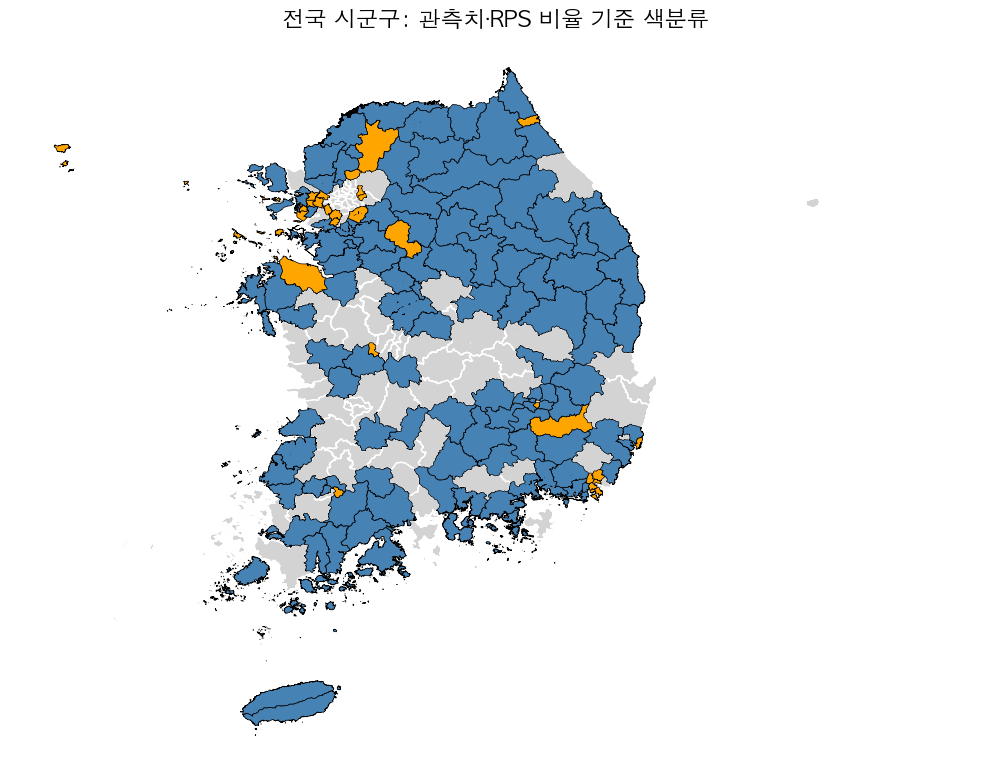

In [18]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import pickle
from pathlib import Path

# ───────────────────────────────────────────────────────────────────────────────
# 1) 파일 경로 설정
BASE_DIR      = Path("/Users/mousebook/Documents/university/연구실/solar/generator/v2/source")
CSV3_PATH     = BASE_DIR / "최종3.csv"
RPS2_PATH     = BASE_DIR / "rps2.csv"
GDF_DICT_PKL  = BASE_DIR / "gdf_dict_v2.pkl"
# ───────────────────────────────────────────────────────────────────────────────

# ────────── A) 데이터 로드 및 집계 ──────────
# 2) 발전소 관측치 (최종3.csv) → 지역별 관측치 개수
df3 = pd.read_csv(CSV3_PATH, encoding="utf-8-sig")
df3["region"] = df3["region_1depth_name"] + " " + df3["region_2depth_name"]
obs_counts = (
    df3["region"]
      .value_counts()
      .rename_axis("region")
      .reset_index(name="obs_count")
)

# 3) RPS 설비 (rps2.csv) → 지역별 b_count 합산
r2 = pd.read_csv(RPS2_PATH, encoding="utf-8-sig")
r2["region"] = r2["region_1depth_name"] + " " + r2["region_2depth_name"]
rps_counts = (
    r2.groupby("region", as_index=False)["b_count"]
      .sum()
)

# 4) 병합 → rps_ratio 계산
merged = (
    pd.merge(obs_counts, rps_counts, on="region", how="outer")
      .fillna(0)
)
merged["obs_count"] = merged["obs_count"].astype(int)
merged["b_count"]   = merged["b_count"].astype(int)
merged["rps_ratio"] = merged.apply(
    lambda r: (r["b_count"] / r["obs_count"])
              if r["obs_count"] > 0 else 0,
    axis=1
)

# 5) 필요하면 region→region_code 매핑
#    (지역코드.csv에서 읽어와도 되지만, 우리가 이미 filter_region_and_get_code...에 매핑이 있으므로
#     SIG_CD를 기준으로 나중에 병합합니다.)

# ────────── B) 지도용 GeoDataFrame 준비 ──────────
# 6) 전국 시군구 경계 불러오기
with open(GDF_DICT_PKL, "rb") as f:
    gdf_dict = pickle.load(f)

gdf_all = gpd.GeoDataFrame(
    pd.concat(gdf_dict.values(), ignore_index=True),
    crs=list(gdf_dict.values())[0].crs
)
# SIG_CD를 정수로
gdf_all["SIG_CD"] = gdf_all["SIG_CD"].astype(int)

# 7) 각 경계에 region 문자열 붙이기
#    (utils.filter_region_and_get_code_and_geom이 mapping_df를 쓰므로, 여기서는 지역코드→region 문자열 매핑을 다시 만듭니다)
codes = pd.read_csv(BASE_DIR / "지역코드.csv",
                    encoding="utf-8-sig", header=0, names=["region","region_code"])
parts = codes["region"].str.strip().str.split(" ", n=1, expand=True)
codes["region_1depth_name"], codes["region_2depth_name"] = parts[0], parts[1]
codes["region_code"] = codes["region_code"].astype(int)
codes["region"] = codes["region_1depth_name"] + " " + codes["region_2depth_name"]

# 병합
gdf_all = gdf_all.merge(
    codes[["region_code","region"]],
    left_on="SIG_CD", right_on="region_code",
    how="left"
)

# 8) 관측치·RPS 비율 데이터와 병합
gdf_all = gdf_all.merge(
    merged[["region","obs_count","rps_ratio"]],
    on="region",
    how="left"
).fillna({"obs_count": 0, "rps_ratio": 0})

# 9) 표시할 지역만 필터 (obs_count > 0)
gdf_plot = gdf_all[gdf_all["obs_count"] > 0].copy()

# 10) 색상 분류
#   - 조건(관측치 ≤30 또는 RPS 비율 ≤0.5): 주황
#   - 나머지: 파랑
gdf_plot["color"] = gdf_plot.apply(
    lambda r: "orange" 
              if (r["obs_count"] <= 30 or r["rps_ratio"] <= 0.5)
              else "steelblue",
    axis=1
)

# ────────── C) 지도 그리기 ──────────
plt.rc("font", family="AppleGothic")
plt.rc("axes", unicode_minus=False)

fig, ax = plt.subplots(figsize=(10,12))
# 배경(관측치 0 지역)
gdf_all[gdf_all["obs_count"] == 0].plot(
    ax=ax, color="lightgray", edgecolor="white"
)
# 조건 만족 지역(주황)
gdf_plot[gdf_plot["color"]=="orange"].plot(
    ax=ax, color="orange", edgecolor="black", linewidth=0.5, label="관측치≤30 또는 RPS≤50%"
)
# 나머지(파랑)
gdf_plot[gdf_plot["color"]=="steelblue"].plot(
    ax=ax, color="steelblue", edgecolor="black", linewidth=0.5, label="나머지(관측치>30 & RPS>50%)"
)

ax.set_title("전국 시군구: 관측치·RPS 비율 기준 색분류", fontsize=16)
ax.axis("off")
ax.legend(loc="lower left", frameon=False)

plt.tight_layout()
plt.show()



### 지역별 설비용량 밀도함수

k별 실루엣 점수:
  k=2: silhouette=0.442
  k=3: silhouette=0.420
  k=4: silhouette=0.415
  k=5: silhouette=0.389
  k=6: silhouette=0.359
  k=7: silhouette=0.355
  k=8: silhouette=0.317
  k=9: silhouette=0.318
  k=10: silhouette=0.317

추천 클러스터 수: k=2


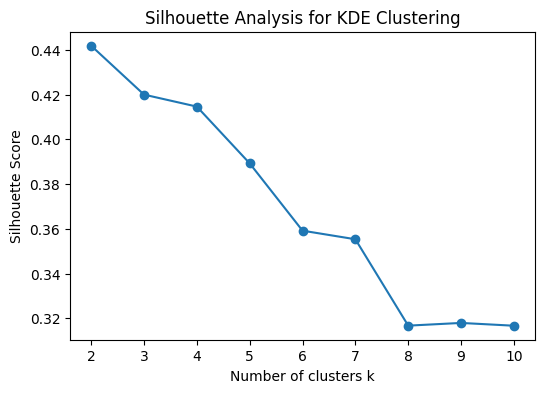

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import gaussian_kde
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from pathlib import Path

# 1) 데이터 불러오기 및 전처리
base_dir  = Path("/Users/mousebook/Documents/university/연구실/solar/generator/v2/source")
csv3_path = base_dir / "최종3.csv"
df = pd.read_csv(csv3_path, encoding="utf-8-sig")
df["설비용량"] = pd.to_numeric(df["설비용량"], errors="coerce")
df["region"] = df["region_1depth_name"] + " " + df["region_2depth_name"]

# 2) 지역별 값 배열 준비
grouped = df.groupby("region")["설비용량"].apply(lambda x: x.dropna().values)

# 3) 공통 그리드 설정
all_vals = df["설비용량"].dropna().values
grid = np.linspace(all_vals.min(), all_vals.max(), 100)

# 4) KDE 벡터 생성
kde_matrix = []
regions   = []
for region, vals in grouped.items():
    if len(vals) < 5:
        continue
    kde_matrix.append(gaussian_kde(vals)(grid))
    regions.append(region)
kde_matrix = np.vstack(kde_matrix)

# 5) 실루엣 분석으로 최적 클러스터 수 탐색
from matplotlib import pyplot as plt

sil_scores = []
ks = range(2, 11)
for k in ks:
    model = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = model.fit_predict(kde_matrix)
    score  = silhouette_score(kde_matrix, labels, metric="euclidean")
    sil_scores.append(score)

# 6) 결과 출력 및 추천 k
best_k = ks[np.argmax(sil_scores)]
print("k별 실루엣 점수:")
for k, s in zip(ks, sil_scores):
    print(f"  k={k}: silhouette={s:.3f}")
print(f"\n추천 클러스터 수: k={best_k}")

# 7) 시각화 (선택)
plt.figure(figsize=(6,4))
plt.plot(ks, sil_scores, marker="o")
plt.xticks(ks)
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis for KDE Clustering")
plt.show()


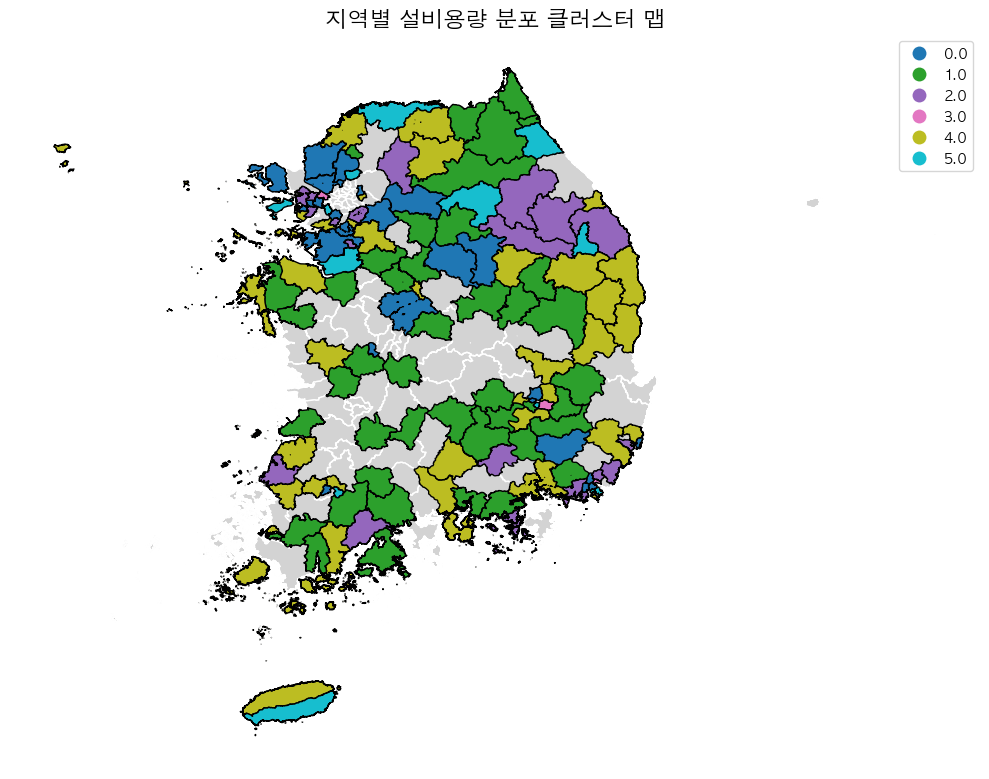

In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
import pickle
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.cluster import AgglomerativeClustering
from pathlib import Path

# —————————————————————————————
# 1) 경로 설정
base_dir   = Path("/Users/mousebook/Documents/university/연구실/solar/generator/v2/source")
csv3_path  = base_dir / "최종3.csv"
codes_path = base_dir / "지역코드.csv"
pkl_path   = base_dir / "gdf_dict_v2.pkl"
# —————————————————————————————

# 2) 데이터 로드 및 전처리
df = pd.read_csv(csv3_path, encoding="utf-8-sig")
df["설비용량"] = pd.to_numeric(df["설비용량"], errors="coerce")
df["region"] = df["region_1depth_name"] + " " + df["region_2depth_name"]

# 3) 지역별 설비용량 배열 준비
grouped = df.groupby("region")["설비용량"].apply(lambda x: x.dropna().values)

# 4) KDE 계산용 그리드
all_vals = df["설비용량"].dropna().values
grid = np.linspace(all_vals.min(), all_vals.max(), 100)

# 5) 각 지역 KDE 계산 및 리스트화
kde_list, labels = [], []
for region, vals in grouped.items():
    if len(vals) < 5:
        continue
    kde_list.append(gaussian_kde(vals)(grid))
    labels.append(region)
kde_matrix = np.vstack(kde_list)

# 6) 군집화
N = 6
cluster_model = AgglomerativeClustering(n_clusters=N, linkage="ward")
clusters = cluster_model.fit_predict(kde_matrix)

# 7) cluster 맵
df_cluster = pd.DataFrame({"region": labels, "cluster": clusters})

# 8) 전국 경계 GeoDataFrame 로드
with open(pkl_path, "rb") as f:
    gdf_dict = pickle.load(f)
gdf_all = gpd.GeoDataFrame(
    pd.concat(gdf_dict.values(), ignore_index=True),
    crs=list(gdf_dict.values())[0].crs
)

# 9) SIG_CD를 정수로 변환
gdf_all["SIG_CD"] = gdf_all["SIG_CD"].astype(int)

# 10) 지역명 매핑 DataFrame 준비
mapping = pd.read_csv(codes_path, encoding="utf-8-sig", header=0, names=["region","region_code"])
mapping["region_code"] = mapping["region_code"].astype(int)
parts = mapping["region"].str.split(" ", n=1, expand=True)
mapping["region_1depth_name"], mapping["region_2depth_name"] = parts[0], parts[1]
mapping["region"] = mapping["region_1depth_name"] + " " + mapping["region_2depth_name"]

# 11) gdf_all에 region, cluster 합치기
gdf_all = gdf_all.merge(
    mapping[["region_code","region"]],
    left_on="SIG_CD", right_on="region_code", how="left"
)
gdf_all = gdf_all.merge(df_cluster, on="region", how="left")

# 12) 지도 그리기
plt.rc("font", family="AppleGothic")
plt.rc("axes", unicode_minus=False)

fig, ax = plt.subplots(figsize=(10, 12))
gdf_all[gdf_all["cluster"].isna()].plot(ax=ax, color="lightgray", edgecolor="white")
gdf_all.dropna(subset=["cluster"]).plot(
    column="cluster", categorical=True, cmap="tab10",
    legend=True, ax=ax, edgecolor="black"
)
ax.set_title("지역별 설비용량 분포 클러스터 맵", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()


### 전체 데이터의 밀도함수를 그린 후에 각 지역별 밀도함수가 전체 데이터의 밀도함수와 같다고 봐도되는지

-> 안됨. True / False = 15 / 127


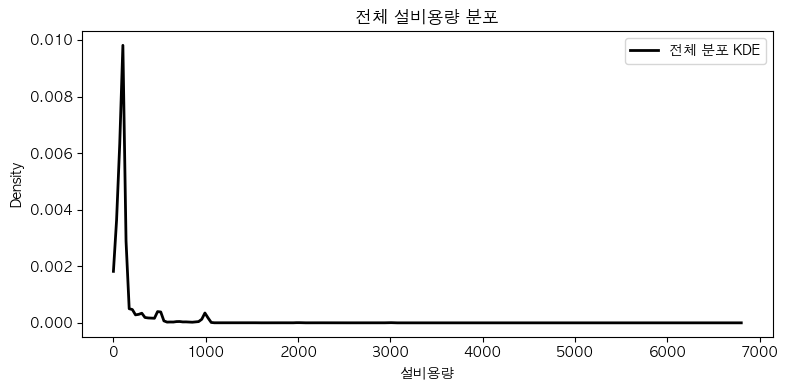

      region  n_region  KS_stat      p_value  same_dist
제주특별자치도 서귀포시       524 0.428471 3.347836e-87      False
      경기 화성시      2034 0.214403 7.014876e-80      False
      충북 청주시      1762 0.225239 8.507870e-77      False
      충남 논산시      2814 0.151933 1.112379e-54      False
 전북특별자치도 익산시      3683 0.132363 1.610843e-53      False
      경남 남해군       368 0.399399 3.399252e-53      False
 전북특별자치도 임실군      1694 0.179646 5.268362e-47      False
      광주 광산구      1151 0.216458 5.861882e-47      False
      경기 광주시       273 0.407009 3.089646e-41      False
      경기 고양시       388 0.342838 5.190210e-41      False
      충북 제천시       336 0.362946 6.278342e-40      False
      전남 영암군      1775 0.161785 6.457894e-40      False
      충북 충주시       841 0.226888 4.963281e-38      False
      전남 영광군       584 0.269235 1.713391e-37      False
      경북 영양군       483 0.276703 6.516633e-33      False
       광주 서구       174 0.448657 1.790538e-32      False
      충남 서산시       844 0.208624 3.045876e-32    

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, ks_2samp
from pathlib import Path

# 1) 데이터 로드 및 전처리
base_dir  = Path("/Users/mousebook/Documents/university/연구실/solar/generator/v2/source")
csv3      = base_dir / "최종3.csv"
df_all    = pd.read_csv(csv3, encoding="utf-8-sig")
df_all["설비용량"] = pd.to_numeric(df_all["설비용량"], errors="coerce")
df_all["region"]   = df_all["region_1depth_name"] + " " + df_all["region_2depth_name"]

# 2) 전체 데이터 밀도함수 계산
values_all = df_all["설비용량"].dropna().values
grid        = np.linspace(values_all.min(), values_all.max(), 200)
kde_all     = gaussian_kde(values_all)
density_all = kde_all(grid)

# 3) 전체 KDE 시각화
plt.figure(figsize=(8, 4))
plt.plot(grid, density_all, color="black", lw=2, label="전체 분포 KDE")
plt.title("전체 설비용량 분포")
plt.xlabel("설비용량")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

# 4) 지역별 가설 검정 (KS 검정)
results = []
for region, group in df_all.groupby("region"):
    vals = group["설비용량"].dropna().values
    if len(vals) < 5:
        continue  # 샘플 수 부족 시 건너뜀
    stat, pval = ks_2samp(vals, values_all)
    results.append({
        "region": region,
        "n_region": len(vals),
        "KS_stat": stat,
        "p_value": pval,
        "same_dist": pval >= 0.05
    })

# 5) 결과 DataFrame으로 정리 및 출력
df_results = pd.DataFrame(results)
df_results = df_results.sort_values("p_value")

print(df_results.to_string(index=False))



지역별로 데이터가 몇 개가 있는지

In [ ]:
import pandas as pd
from pathlib import Path

# 1) 파일 경로 (본인 환경에 맞춰 조정하세요)
base = Path("/Users/mousebook/Documents/university/연구실/solar/generator/v2/source")
csv3 = base / "최종3.csv"
rps2 = base / "rps2.csv"

# 2) 데이터 로드
df3 = pd.read_csv(csv3, encoding="utf-8-sig")
r2  = pd.read_csv(rps2, encoding="utf-8-sig")

# 3) region 컬럼 생성 (최종3.csv)
df3["region"] = df3["region_1depth_name"] + " " + df3["region_2depth_name"]

# 4) region 컬럼 생성 (rps2.csv)
r2["region"] = r2["region_1depth_name"] + " " + r2["region_2depth_name"]

# 5) 최종3.csv의 지역별 관측치 개수 계산
obs_counts = (
    df3["region"]
    .value_counts()
    .rename_axis("region")
    .reset_index(name="obs_count")
)

# 6) rps2.csv의 지역별 b_count 합산
rps_counts = (
    r2.groupby("region", as_index=False)["b_count"]
    .sum()
)

# 7) 두 테이블 병합
merged = pd.merge(
    obs_counts,               # 관측치 개수
    rps_counts,               # RPS 설비 개수
    on="region",
    how="outer"               # 어느 쪽에만 있어도 모두 포함
).fillna(0)                   # 누락된 값은 0으로 처리

# 8) 정수형으로 변환
merged["obs_count"] = merged["obs_count"].astype(int)
merged["b_count"]   = merged["b_count"].astype(int)

# 9) 관측치 많은 순으로 정렬해 출력
merged = merged.sort_values("obs_count", ascending=False)

print(merged.to_string(index=False))


         region  obs_count  b_count
    전북특별자치도 익산시       3683     5706
         충남 논산시       2814     3232
         경기 화성시       2034     2322
         경북 안동시       1912     2319
         전남 영암군       1775     2324
         충북 청주시       1762     2748
    전북특별자치도 임실군       1694     1964
         충남 아산시       1383     1517
         경북 경산시       1203     1389
         광주 광산구       1151     1336
         경북 영주시       1125     1629
    전북특별자치도 부안군       1088     1848
         경북 영천시       1006     1807
         경남 합천군        955     1333
         충남 금산군        948     1718
         경북 예천군        887     1658
         충남 부여군        875     1696
         경기 안성시        854     1677
         충남 서산시        844     1517
         충북 충주시        841     1457
         전남 고흥군        787     1938
         전남 순천시        774     1666
         경남 김해시        714     1054
    강원특별자치도 원주시        700     1294
         경기 연천군        699      867
         경기 여주시        697     1342
         경남 거창군        692  

전체 용량 클러스터링

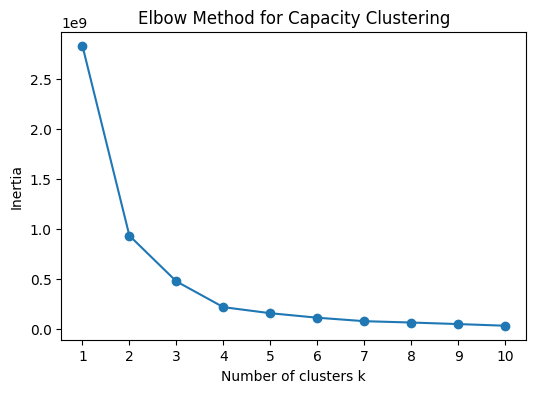

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from pathlib import Path

# 1) 데이터 로드
base_dir = Path("/Users/mousebook/Documents/university/연구실/solar/generator/v2/source")
df = pd.read_csv(base_dir / "최종3.csv", encoding="utf-8-sig")

# 2) 설비용량 숫자형 변환 & 결측치 제거
df["capacity"] = pd.to_numeric(df["설비용량"], errors="coerce")
values = df["capacity"].dropna().values.reshape(-1, 1)

# 3) Elbow Method로 적절한 k 찾기
inertia = []
ks = range(1, 11)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(values)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(ks, inertia, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.title("Elbow Method for Capacity Clustering")
plt.xticks(ks)
plt.show()


 cluster  count        mean    min     max
       0  54005   85.100985   0.00  256.41
       1   1983 1089.843814 758.88 6800.00
       2   4916  427.926077 256.50  758.18


/var/folders/yp/634kdqps0b7_jlvj3j_q0n8c0000gn/T/ipykernel_26492/3458647901.py:23: UserWarning: Glyph 49444 (\N{HANGUL SYLLABLE SEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/yp/634kdqps0b7_jlvj3j_q0n8c0000gn/T/ipykernel_26492/3458647901.py:23: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/yp/634kdqps0b7_jlvj3j_q0n8c0000gn/T/ipykernel_26492/3458647901.py:23: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/yp/634kdqps0b7_jlvj3j_q0n8c0000gn/T/ipykernel_26492/3458647901.py:23: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/yp/634kdqps0b7_jlvj3j_q0n8c0000gn/T/ipykernel_26492/3458647901.py:23: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/yp/634kdqps0b7_jlvj3j_q0n8c0000gn/T/ipy

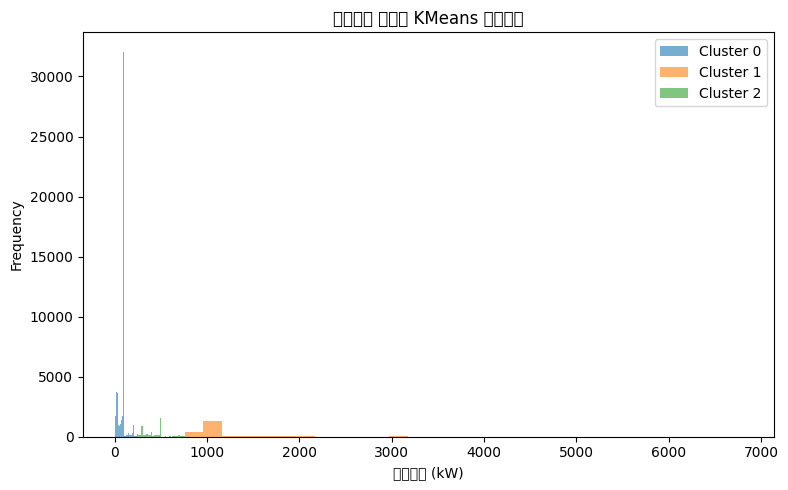

In [14]:
k_opt = 3
kmeans = KMeans(n_clusters=k_opt, random_state=42)
df["cluster"] = kmeans.fit_predict(values)

# 5) 클러스터별 요약 통계
summary = (
    df.groupby("cluster")["capacity"]
      .agg(count="count", mean="mean", min="min", max="max")
      .reset_index()
      .sort_values("cluster")
)
print(summary.to_string(index=False))

# 6) 히스토그램으로 군집별 분포 확인
plt.figure(figsize=(8,5))
for cl in range(k_opt):
    subset = df.loc[df["cluster"] == cl, "capacity"]
    plt.hist(subset, bins=30, alpha=0.6, label=f"Cluster {cl}", color=plt.cm.tab10(cl))
plt.xlabel("설비용량 (kW)")
plt.ylabel("Frequency")
plt.title("설비용량 분포별 KMeans 클러스터")
plt.legend()
plt.tight_layout()
plt.show()

지역별로 K=3 으로 클러스터링 진행 후 각 지역별 클러스터의 범위 계산

In [18]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from pathlib import Path

# 1) 파일 경로 설정 (환경에 맞게 조정)
base_dir   = Path("/Users/mousebook/Documents/university/연구실/solar/generator/v2/source")
csv_path   = base_dir / "최종3.csv"

# 2) 데이터 불러오기 및 전처리
df = pd.read_csv(csv_path, encoding="utf-8-sig")
df["capacity"] = pd.to_numeric(df["설비용량"], errors="coerce")
df["region"]   = df["region_1depth_name"] + " " + df["region_2depth_name"]

# 3) 관측치가 30개 이상인 지역만 추출
region_counts       = df["region"].value_counts()
regions_to_cluster  = region_counts[region_counts >= 30].index.tolist()

# 4) 결과 저장할 리스트
summary_rows = []

# 5) 각 지역별로 3개 군집화 & 범위 계산
for region in regions_to_cluster:
    # 해당 지역 데이터
    vals = df.loc[df["region"] == region, "capacity"].dropna().values.reshape(-1, 1)
    
    # KMeans(3 clusters)
    km = KMeans(n_clusters=3, random_state=42)
    labels = km.fit_predict(vals)
    
    # 군집별 min/max, width 계산
    df_tmp = pd.DataFrame({"capacity": vals.flatten(), "cluster": labels})
    stats  = df_tmp.groupby("cluster")["capacity"].agg(
        min_cap="min", max_cap="max"
    )
    stats["width"] = stats["max_cap"] - stats["min_cap"]
    
    # 시작값(min_cap) 작은 순으로 정렬
    stats = stats.sort_values("min_cap")
    
    # 한 줄에 정렬된 세 개 범위 담기
    ranges = stats.apply(lambda r: f"{r.min_cap:.2f} ~ {r.max_cap:.2f}", axis=1).tolist()
    
    # 출력용 행 작성
    row = {"region": region}
    for i, rng in enumerate(ranges, start=1):
        row[f"cluster_range_{i}"] = rng
    summary_rows.append(row)

# 6) DataFrame으로 변환 후 출력
df_summary = pd.DataFrame(summary_rows)
df_summary = df_summary.sort_values("region").reset_index(drop=True)

print(df_summary.to_string(index=False))


      region cluster_range_1  cluster_range_2   cluster_range_3
 강원특별자치도 고성군  10.00 ~ 234.00  294.15 ~ 655.20  750.00 ~ 1828.96
 강원특별자치도 동해시   9.00 ~ 226.00  276.00 ~ 564.10   887.00 ~ 999.00
 강원특별자치도 삼척시  10.00 ~ 501.51 584.40 ~ 1390.00 1732.64 ~ 3000.00
 강원특별자치도 양구군   9.00 ~ 137.28  184.00 ~ 383.00   449.00 ~ 994.00
 강원특별자치도 양양군  18.48 ~ 270.72  432.00 ~ 998.40 1400.00 ~ 2016.00
 강원특별자치도 영월군  10.00 ~ 208.05  243.82 ~ 500.00  723.32 ~ 1890.00
 강원특별자치도 원주시   3.00 ~ 251.37  297.00 ~ 702.00  799.50 ~ 2003.22
 강원특별자치도 인제군  19.72 ~ 233.92  291.84 ~ 695.33 1305.15 ~ 1598.40
 강원특별자치도 정선군  14.94 ~ 499.80 540.00 ~ 1048.00 1699.00 ~ 2750.00
 강원특별자치도 철원군  10.00 ~ 498.96 797.50 ~ 1496.88 2004.00 ~ 2494.80
 강원특별자치도 춘천시   8.00 ~ 545.40 765.20 ~ 2050.00 2900.00 ~ 2965.41
 강원특별자치도 태백시  13.00 ~ 600.00 732.00 ~ 2016.90 6800.00 ~ 6800.00
 강원특별자치도 평창군  15.00 ~ 259.88  270.00 ~ 700.80  806.40 ~ 2300.00
 강원특별자치도 홍천군   5.00 ~ 494.76 664.83 ~ 1670.00 2349.18 ~ 2996.46
 강원특별자치도 화천군   8.10 ~ 299.83  317.44 ~ 7

# 설치연도

설치연도 밀도함수

설치연도 null 개수: 0


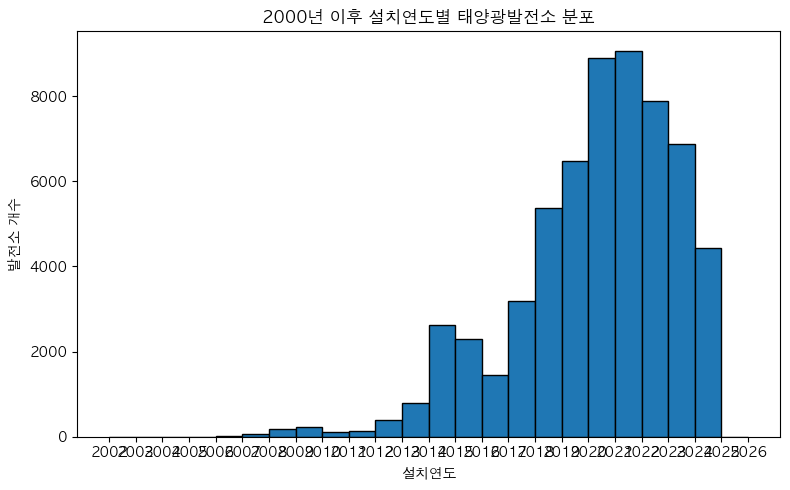

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 1) 최종3.csv 불러오기
base_dir = Path("/Users/mousebook/Documents/university/연구실/solar/generator/v2/source")
csv_path = base_dir / "최종3.csv"
df3 = pd.read_csv(csv_path, encoding="utf-8-sig")

# 2) 설치연도 null 개수 확인
null_count = df3["설치연도"].isna().sum()
print(f"설치연도 null 개수: {null_count}")

# 3) 1950년 이전 데이터 제거
df3["설치연도"] = pd.to_numeric(df3["설치연도"], errors="coerce")
df3 = df3[df3["설치연도"] >= 2000]

# 4) 히스토그램 그리기
years = df3["설치연도"].astype(int)

plt.figure(figsize=(8, 5))
bins = range(years.min(), years.max() + 2)  # 연도별로 한 칸씩
plt.hist(years, bins=bins, edgecolor="black")
plt.xlabel("설치연도")
plt.ylabel("발전소 개수")
plt.title("2000년 이후 설치연도별 태양광발전소 분포")
plt.xticks(bins)
plt.tight_layout()
plt.show()


In [4]:
# 4) 설치연도 최소값 확인
min_year = pd.to_numeric(df3["설치연도"], errors="coerce").dropna().astype(int).min()
print(f"설치연도 최소값: {min_year}")


설치연도 최소값: 1900


# 변전소

변전소 그려보기 (서울)

▶ 서울시 전체 변전소 개수: 20개
   - Point 타입: 0개
   - 기타 타입(LineString, Polygon 등): 20개


ValueError: aspect must be finite and positive 

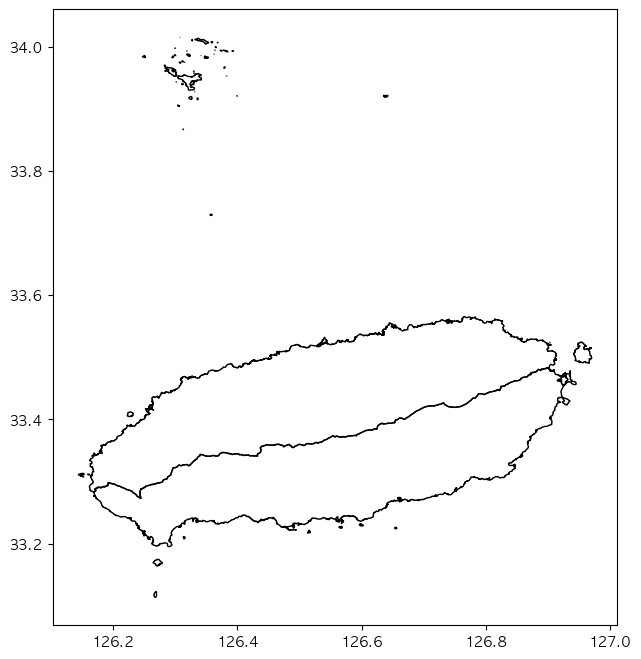

In [15]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import pickle

from utils import get_substations_by_region  # 기존 함수 재활용

# ─ 설정 ───────────────────────────────────────────────────
BASE_DIR   = Path("/Users/mousebook/Documents/university/연구실/solar/generator/v2/source")
CODES_CSV  = BASE_DIR / "지역코드.csv"
GDF_DICT   = BASE_DIR / "gdf_dict_v2.pkl"
SUBS_GEO   = BASE_DIR / "filtered_substations.geojson"
# ─────────────────────────────────────────────────────────

# 1) 지역코드.csv 로드
df_codes = pd.read_csv(
    CODES_CSV,
    encoding="utf-8-sig",
    header=0,
    names=["region","region_code"]
)
parts = df_codes["region"].str.strip().str.split(" ", n=1, expand=True)
df_codes["depth1"]       = parts[0]
df_codes["depth2"]       = parts[1]
df_codes["region_code"]  = df_codes["region_code"].astype(int)

# 2) '서울'만 추출
df_seoul = df_codes[df_codes["depth1"] == "제주특별자치도"]

# 3) 시군구 경계 로드
with open(GDF_DICT, "rb") as f:
    gdf_dict = pickle.load(f)

def get_region_boundary(region_code: int) -> gpd.GeoDataFrame:
    prov_key = str(region_code)[:2]
    gdf_prov = gdf_dict.get(prov_key)
    mask     = gdf_prov["SIG_CD"].astype(int) == region_code
    return gdf_prov.loc[mask].copy()

# 4) 서울 전역 경계 모으기
boundaries = [get_region_boundary(code) for code in df_seoul["region_code"]]
gdf_seoul = gpd.GeoDataFrame(
    pd.concat(boundaries, ignore_index=True),
    crs=boundaries[0].crs
)

# 5) 서울 전역 변전소 모으기
subs_list = [get_substations_by_region(code) for code in df_seoul["region_code"]]
gdf_subs_seoul = gpd.GeoDataFrame(
    pd.concat(subs_list, ignore_index=True),
    crs=subs_list[0].crs
)

# 5.1) 변전소 개수 출력
total = len(gdf_subs_seoul)
points = len(gdf_subs_seoul[gdf_subs_seoul.geometry.type == "Point"])
others = total - points
print(f"▶ 서울시 전체 변전소 개수: {total}개")
print(f"   - Point 타입: {points}개")
print(f"   - 기타 타입(LineString, Polygon 등): {others}개")

# 6) 시각화
plt.rc("font", family="AppleGothic")
plt.rc("axes", unicode_minus=False)

fig, ax = plt.subplots(figsize=(8,8))
gdf_seoul.boundary.plot(ax=ax, edgecolor="black", linewidth=1)

pts   = gdf_subs_seoul[gdf_subs_seoul.geometry.type=="Point"]
other = gdf_subs_seoul[gdf_subs_seoul.geometry.type!="Point"]

pts.plot(ax=ax,   marker="o", color="red",   markersize=20, label="Point")
other.plot(ax=ax, marker="x", color="blue",  markersize=10, label="Other")

ax.set_title("서울시 전역 변전소 위치", fontsize=16)
ax.axis("off")
ax.legend()
plt.tight_layout()
plt.show()


충남 논산시, 변전소와 발전소 그리기

▶ 충남 논산시 변전소 개수: 2개
▶ 충남 논산시 발전소 개수: 2814개


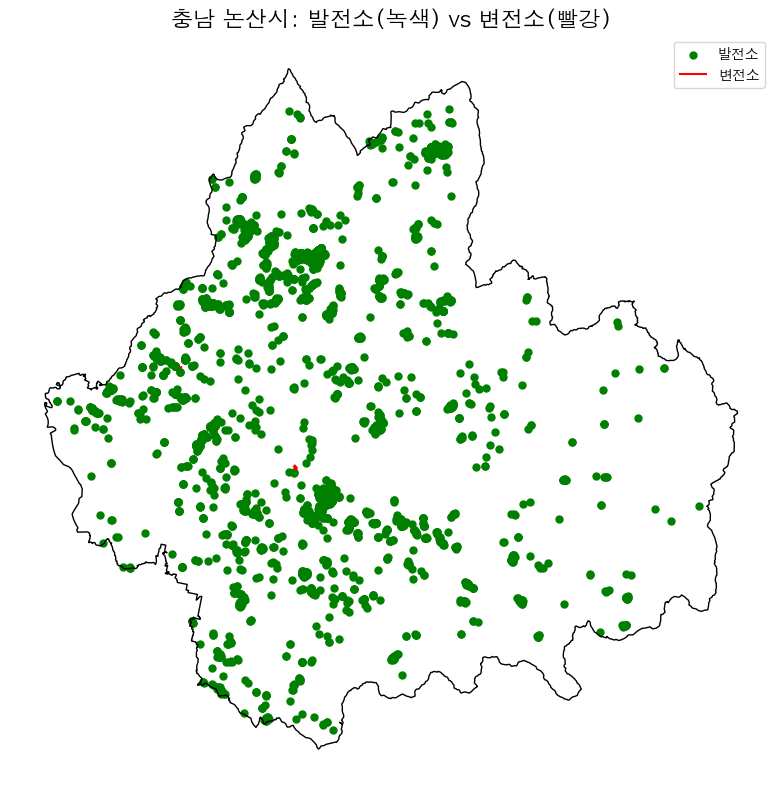

In [19]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import pickle

from utils import filter_region_and_get_code_and_geom, get_substations_by_region

# ─ 설정 ───────────────────────────────────────────────────
BASE_DIR = Path(
    "/Users/mousebook/Documents/university/연구실/solar/generator/v2/source"
)
CODES_CSV = BASE_DIR / "지역코드.csv"
GDF_DICT_PKL = BASE_DIR / "gdf_dict_v2.pkl"
SUBS_GEOJSON = BASE_DIR / "filtered_substations.geojson"
PLANT_CSV = BASE_DIR / "최종3.csv"
# ─────────────────────────────────────────────────────────

# 1)  가져오기
depth1, depth2 = "충남", "논산시"
_, region_code, gdf_region = filter_region_and_get_code_and_geom(depth1, depth2)

# 2) 변전소(Subs) 불러오기
gdf_subs = get_substations_by_region(region_code)

# 3) 발전소(Plants) 불러오기 : 최종3.csv 에서 x,y → Point
df_plants = pd.read_csv(PLANT_CSV, encoding="utf-8-sig")
df_plants["x"] = pd.to_numeric(df_plants["x"], errors="coerce")
df_plants["y"] = pd.to_numeric(df_plants["y"], errors="coerce")
mask = (df_plants["region_1depth_name"] == depth1) & (
    df_plants["region_2depth_name"] == depth2
)
df_plants_loc = df_plants.loc[mask].dropna(subset=["x", "y"]).copy()

gdf_plants = gpd.GeoDataFrame(
    df_plants_loc,
    geometry=gpd.points_from_xy(df_plants_loc["x"], df_plants_loc["y"]),
    crs="EPSG:4326",
)

# 4) 개수 출력
n_subs = len(gdf_subs)
n_plants = len(gdf_plants)
print(f"▶ 충남 논산시 변전소 개수: {n_subs}개")
print(f"▶ 충남 논산시 발전소 개수: {n_plants}개")

# 5) 시각화
plt.rc("font", family="AppleGothic")
plt.rc("axes", unicode_minus=False)

fig, ax = plt.subplots(figsize=(8, 8))
# 경계
gdf_region.boundary.plot(ax=ax, edgecolor="black", linewidth=1)

# 발전소는 녹색 원
gdf_plants.plot(ax=ax, marker="o", color="green", markersize=25, label="발전소")
# 변전소는 빨간 X
gdf_subs.plot(ax=ax, marker="o", color="red", markersize=50, label="변전소")

ax.set_title("충남 논산시: 발전소(녹색) vs 변전소(빨강)", fontsize=16)
ax.axis("off")
ax.legend()

plt.tight_layout()
plt.show()

### 변전소의 수와 고용량 설비의 비율이 상관관계가 있는지.

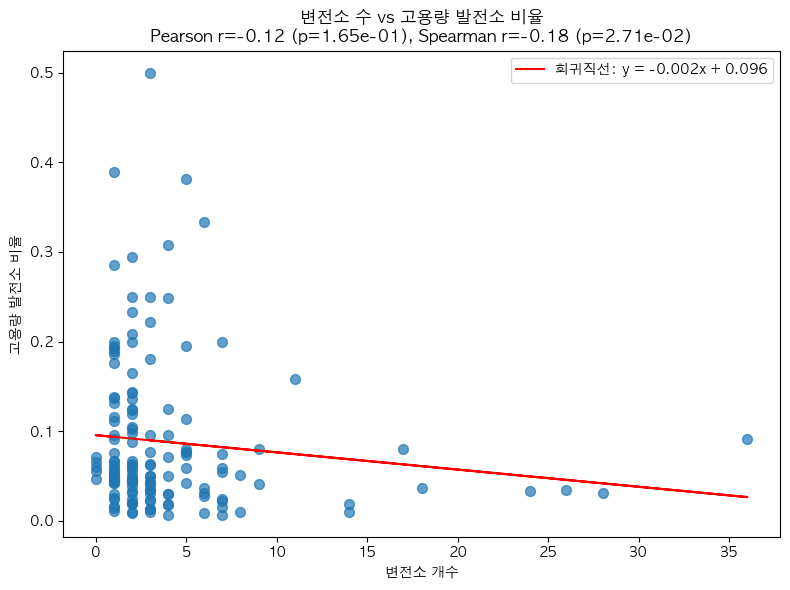

▶ Pearson 상관계수: r = -0.116, p-value = 1.65e-01
▶ Spearman 상관계수: r = -0.184, p-value = 2.71e-02


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.stats import pearsonr, spearmanr

from utils import load_region_pairs, filter_region_and_get_code_and_geom

# ───────────────────────────────────────────────────────────────
# 1) 변전소 매핑 테이블 로드 (orig_idx→SIG_CD)
subs_map = pd.read_csv(
    "/Users/mousebook/Documents/university/연구실/solar/generator/v2/source/subs_region_mapping.csv",
    encoding="utf-8-sig",
    dtype={"orig_idx": "Int64", "SIG_CD": "Int64"}
)

# NA 있는 행은 제거
subs_map = subs_map.dropna(subset=["orig_idx", "SIG_CD"])
subs_map["orig_idx"] = subs_map["orig_idx"].astype(int)
subs_map["SIG_CD"]   = subs_map["SIG_CD"].astype(int)

# region_code별 변전소 개수 집계 → 컬럼명 바꿔주기
subs_count = (
    subs_map
      .groupby("SIG_CD")["orig_idx"]
      .count()
      .rename("substation_count")
      .reset_index()
      .rename(columns={"SIG_CD": "region_code"})
)
# ───────────────────────────────────────────────────────────────



# ───────────────────────────────────────────────────────────────
# 2) 각 지역별 “고용량 클러스터 비율” 계산
records = []
for depth1, depth2 in load_region_pairs():
    try:
        sub_df, region_code, _ = filter_region_and_get_code_and_geom(depth1, depth2)
    except Exception:
        continue

    # 설비용량 배열
    caps = (
        pd.to_numeric(sub_df["설비용량"], errors="coerce")
          .dropna()
          .values
          .reshape(-1, 1)
    )
    if len(caps) < 2:
        continue  # 너무 적어서 건너뛰기

    # k=2 클러스터링
    km = KMeans(n_clusters=2, random_state=0).fit(caps)
    centers = km.cluster_centers_.flatten()
    high_label = centers.argmax()

    high_ratio = (km.labels_ == high_label).mean()
    records.append({"region_code": region_code, "high_ratio": high_ratio})

df_high = pd.DataFrame(records)
# ───────────────────────────────────────────────────────────────



# ───────────────────────────────────────────────────────────────
# 3) 병합 및 NA 처리
df = (
    df_high
      .merge(subs_count, on="region_code", how="left")
      .fillna({"substation_count": 0})
)
# ───────────────────────────────────────────────────────────────



# ───────────────────────────────────────────────────────────────
# 4) 분석: 상관·회귀
if df.shape[0] < 2:
    print("분석할 충분한 지역 데이터가 없습니다.")
else:
    x = df["substation_count"].values
    y = df["high_ratio"].values

    pearson_r, pearson_p   = pearsonr(x, y)
    spearman_r, spearman_p = spearmanr(x, y)
    m, b = np.polyfit(x, y, 1)

    plt.rc("font", family="AppleGothic")
    plt.rc("axes", unicode_minus=False)

    plt.figure(figsize=(8,6))
    plt.scatter(x, y, alpha=0.7, s=50)
    plt.plot(x, m*x + b, color="red",
             label=f"회귀직선: y = {m:.3f}x + {b:.3f}")
    plt.title(
        "변전소 수 vs 고용량 발전소 비율\n"
        f"Pearson r={pearson_r:.2f} (p={pearson_p:.2e}), "
        f"Spearman r={spearman_r:.2f} (p={spearman_p:.2e})"
    )
    plt.xlabel("변전소 개수")
    plt.ylabel("고용량 발전소 비율")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"▶ Pearson 상관계수: r = {pearson_r:.3f}, p-value = {pearson_p:.2e}")
    print(f"▶ Spearman 상관계수: r = {spearman_r:.3f}, p-value = {spearman_p:.2e}")


패널의 갯수가 N개 이상인 지역 분포 보기

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# —————————————————————————————
# 한글 깨짐 방지 폰트 설정 (Mac: AppleGothic / Windows: Malgun Gothic 등)
plt.rc("font", family="AppleGothic")
plt.rc("axes", unicode_minus=False)

# 파일 경로 설정
BASE_DIR = "/Users/mousebook/Documents/university/연구실/solar/generator/v2/source"
RPS_CSV    = f"{BASE_DIR}/rps2.csv"
FINAL3_CSV = f"{BASE_DIR}/최종3.csv"

# (1) 데이터 로드
rps = pd.read_csv(RPS_CSV, encoding="utf-8-sig")
df  = pd.read_csv(FINAL3_CSV, encoding="utf-8-sig")
df["설비용량"] = pd.to_numeric(df["설비용량"], errors="coerce")

# (2) 임계값 설정
N = 1000  # 원하는 패널 개수 기준으로 수정하세요

# (3) b_count ≥ N인 지역만 추출
selected = rps[rps["b_count"] >= N]

# (4) 지역별로 히스토그램 그리기
for _, row in selected.iterrows():
    depth1 = row["region_1depth_name"]  # 예: '서울'
    depth2 = row["region_2depth_name"]  # 예: '성동구'
    
    # 최종3에서 해당 지역 데이터만 필터
    sub = df[
        (df["region_1depth_name"] == depth1) &
        (df["region_2depth_name"] == depth2)
    ]
    if sub.empty:
        print(f"데이터 없음: {depth1} {depth2}")
        continue
    
    # 히스토그램
    plt.figure(figsize=(6, 4))
    plt.hist(sub["설비용량"].dropna(), bins=25, edgecolor="black", alpha=0.7)
    plt.title(f"{depth1} {depth2} (b_count ≥ {N}) 설비용량 분포")
    plt.xlabel("설비용량 (kW)")
    plt.ylabel("빈도")
    plt.grid(linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


# power line

전국 시각화

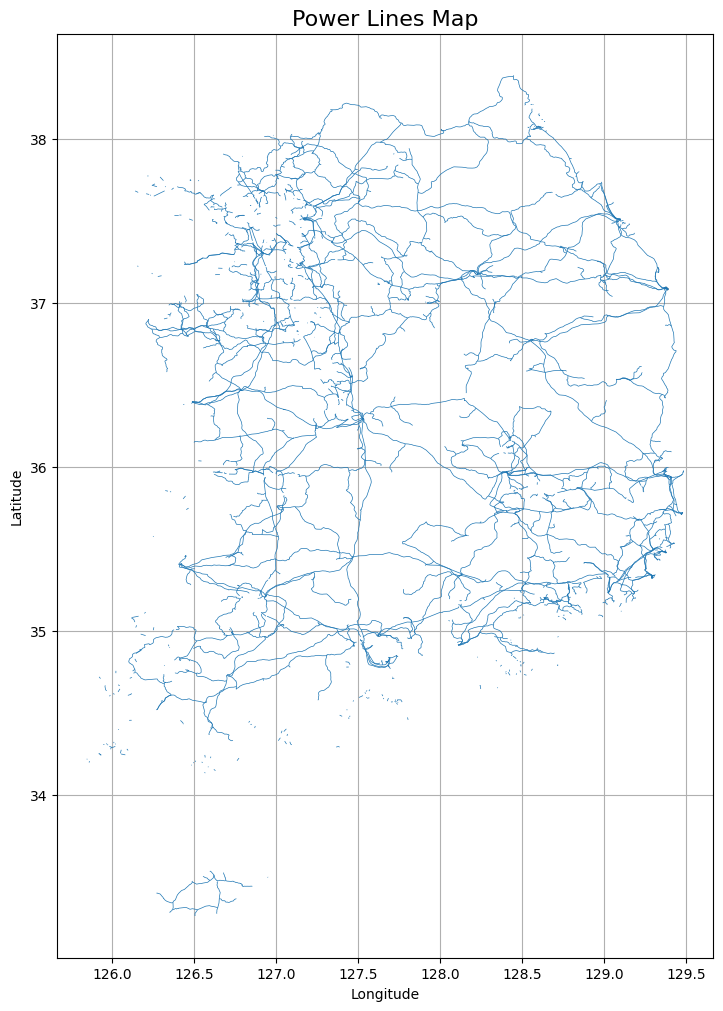

In [1]:
import json
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import shape

# 파일 경로
input_file = '/Users/mousebook/Documents/university/연구실/solar/generator/v2/source/openstreetmap/filtered_power_lines.geojson'

# GeoJSON 파일 읽기
with open(input_file, 'r', encoding='utf-8') as f:
    data = json.load(f)

# GeoPandas를 이용해 Feature들을 읽어오기
geometries = []
properties = []

for feature in data['features']:
    geom = shape(feature['geometry'])
    geometries.append(geom)
    properties.append(feature['properties'])

gdf = gpd.GeoDataFrame(properties, geometry=geometries)

# 시각화
fig, ax = plt.subplots(figsize=(12, 12))
gdf.plot(ax=ax, linewidth=0.5)
ax.set_title('Power Lines Map', fontsize=16)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.grid(True)
plt.show()


배전선만 그리기

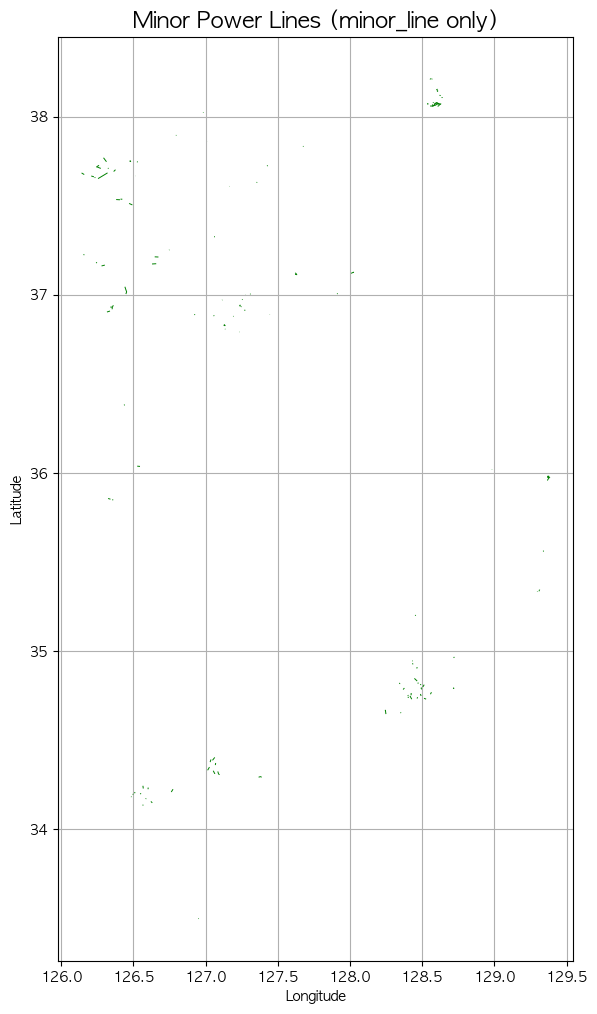

In [10]:
import json
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import shape

# 파일 경로
input_file = '/Users/mousebook/Documents/university/연구실/solar/generator/v2/source/filtered_power_lines.geojson'

# GeoJSON 파일 읽기
with open(input_file, 'r', encoding='utf-8') as f:
    data = json.load(f)

# GeoPandas를 이용해 Feature들을 읽어오기
geometries = []
properties = []

for feature in data['features']:
    geom = shape(feature['geometry'])
    geometries.append(geom)
    properties.append(feature['properties'])

gdf = gpd.GeoDataFrame(properties, geometry=geometries, crs="EPSG:4326")  # 좌표계 설정 추가

# 🔥 minor_line만 필터링
gdf_minor_lines = gdf[gdf['power'] == 'minor_line']

# 시각화
fig, ax = plt.subplots(figsize=(12, 12))
gdf_minor_lines.plot(ax=ax, linewidth=0.7, color='green')
ax.set_title('Minor Power Lines (minor_line only)', fontsize=16)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.grid(True)
plt.show()


변전소 + 발전소 + 전선

▶ 강원특별자치도 삼척시 변전소: 3개
▶ 강원특별자치도 삼척시 발전소(≥300㎾): 92개
▶ 강원특별자치도 삼척시 송전선(line): 20개
▶ 강원특별자치도 삼척시 배전선(minor_line): 0개


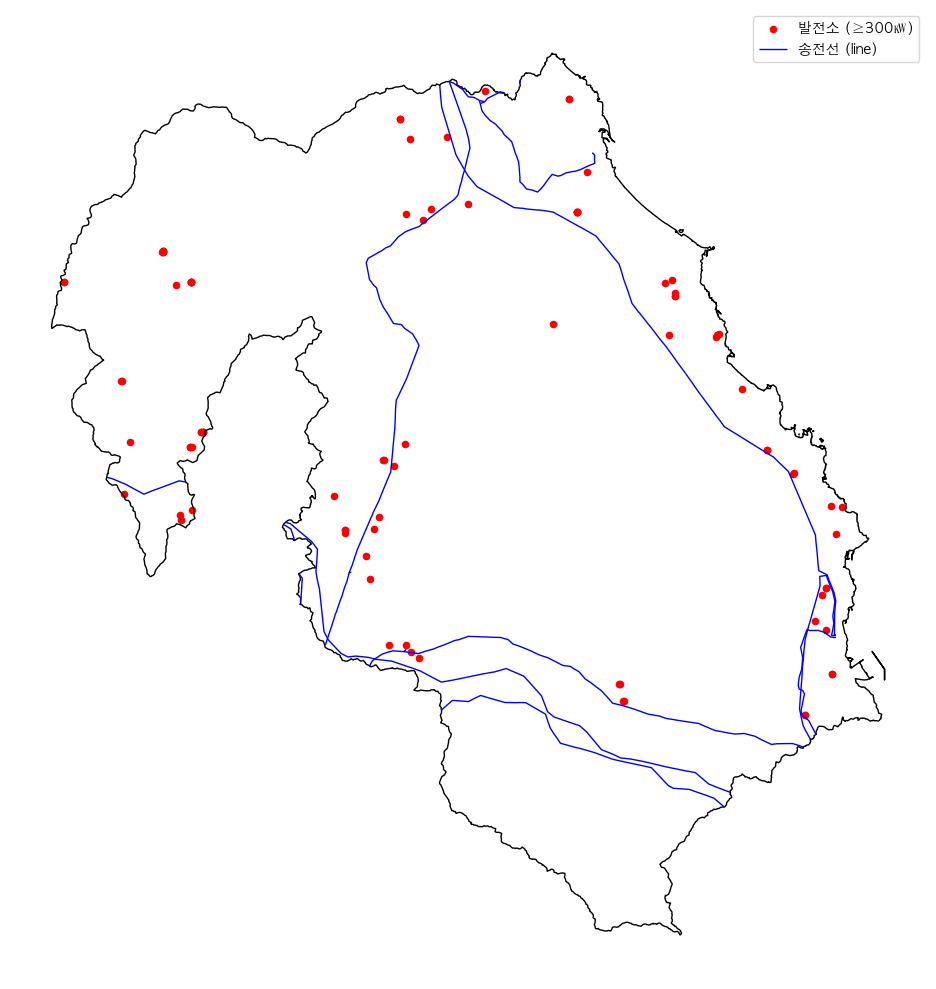

In [1]:
import pandas as pd
import geopandas as gpd
from geopandas.tools import clip 
import matplotlib.pyplot as plt
import pickle
import json
from shapely.geometry import shape
from pathlib import Path


from utils import (
    filter_region_and_get_code_and_geom,
    get_substations_by_region,
    plot_mountain_base
)

# ───────────────────────────────────────────────────────────────
# 1) 경로 정의
BASE_DIR         = Path("/Users/mousebook/Documents/university/연구실/solar/generator/v2/source")
PLANT_CSV        = BASE_DIR / "최종3.csv"
POWER_LINES_JSON = BASE_DIR / "openstreetmap" /"filtered_power_lines.geojson"
# ───────────────────────────────────────────────────────────────

# 2) 분석 대상 지역 설정
지역 = '강원특별자치도 삼척시'
depth1, depth2 = 지역.split(" ")

def draw(depth1: str, depth2: str):
    # 3) 행정구역 경계 + 산·비산지 정보 가져오기
    _, region_code, gdf_region = filter_region_and_get_code_and_geom(depth1, depth2)

    # 4) 밑그림: 산지·비산지
    fig, ax = plot_mountain_base(
        gdf_region,
        figsize=(10,10)
    )

    # 5) 변전소(substations)
    gdf_subs = get_substations_by_region(region_code)

    # 6) 발전소(plants) 불러오기 & 필터링 (설비용량 ≥ 300)
    df_plants = pd.read_csv(PLANT_CSV, encoding="utf-8-sig")
    df_plants["x"] = pd.to_numeric(df_plants["x"], errors="coerce")
    df_plants["y"] = pd.to_numeric(df_plants["y"], errors="coerce")
    df_plants["설비용량"] = pd.to_numeric(df_plants["설비용량"], errors="coerce")

    mask = (
        (df_plants["region_1depth_name"] == depth1) &
        (df_plants["region_2depth_name"] == depth2) &
        (df_plants["설비용량"] >= 300)
    )
    df_plants_loc = df_plants.loc[mask].dropna(subset=["x","y"])
    gdf_plants = gpd.GeoDataFrame(
        df_plants_loc,
        geometry=gpd.points_from_xy(df_plants_loc["x"], df_plants_loc["y"]),
        crs="EPSG:4326"
    )

    # 7) 전선(power lines) 불러오기 및 클립
    with open(POWER_LINES_JSON, "r", encoding="utf-8") as f:
        js = json.load(f)
    geoms, props = [], []
    for feat in js["features"]:
        geoms.append(shape(feat["geometry"]))
        props.append(feat["properties"])
    gdf_lines = gpd.GeoDataFrame(props, geometry=geoms, crs="EPSG:4326")

    # —— 여기서부터 변경 —— #
    # 7.1) 경계 안으로 잘라내기 (clip)
    gdf_lines = clip(gdf_lines, gdf_region)

    # 7.2) 전압별 분리
    gdf_high = gdf_lines[gdf_lines["power"] == "line"]
    gdf_low  = gdf_lines[gdf_lines["power"] == "minor_line"]
    # —— 변경 끝 —— #

    # 8) 개수 출력
    print(f"▶ {depth1} {depth2} 변전소: {len(gdf_subs)}개")
    print(f"▶ {depth1} {depth2} 발전소(≥300㎾): {len(gdf_plants)}개")
    print(f"▶ {depth1} {depth2} 송전선(line): {len(gdf_high)}개")
    print(f"▶ {depth1} {depth2} 배전선(minor_line): {len(gdf_low)}개")


    # 9) overlay
    if not gdf_plants.empty:
        gdf_plants.plot(
            ax=ax, marker="o", color="red", markersize=20,
            label="발전소 (≥300㎾)"
        )
    # if not gdf_subs.empty:
    #     gdf_subs.plot(
    #         ax=ax, marker="x", color="red", markersize=60,
    #         label="변전소"
    #     )
    if not gdf_high.empty:
        gdf_high.plot(
            ax=ax, color="blue", linewidth=1, label="송전선 (line)"
        )
    if not gdf_low.empty:
        gdf_low.plot(
            ax=ax, color="lightgreen", linewidth=1, label="배전선 (minor_line)"
        )

    ax.legend(loc="upper right")
    plt.show()

# 실제 그리기 호출
draw(depth1, depth2)


송전선 근처에 변압기가 있는것에 대한 타당성

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import json
from shapely.geometry import shape, Polygon, LineString, MultiLineString
from shapely import affinity
from pathlib import Path
from tqdm import tqdm

from utils import (
    filter_region_and_get_code_and_geom,
    get_substations_by_region,
    plot_mountain_base
)

# ───────────────────────────────────────────────────────────────
# 경로 설정
BASE_DIR         = Path("/Users/mousebook/Documents/university/연구실/solar/generator/v2/source")
PLANT_CSV        = BASE_DIR / "최종3.csv"
POWER_LINES_JSON = BASE_DIR / "filtered_power_lines.geojson"
# ───────────────────────────────────────────────────────────────

def prepare_region(depth1: str, depth2: str):
    _, region_code, gdf_region = filter_region_and_get_code_and_geom(depth1, depth2)
    if gdf_region.crs is None:
        gdf_region.set_crs(epsg=4326, inplace=True)
    fig, ax = plot_mountain_base(
        gdf_region,
        title=f"{depth1} {depth2} 산지·비산지 밑그림",
        figsize=(10,10)
    )

    df = pd.read_csv(PLANT_CSV, encoding="utf-8-sig")
    df["x"] = pd.to_numeric(df["x"], errors="coerce")
    df["y"] = pd.to_numeric(df["y"], errors="coerce")
    df["설비용량"] = pd.to_numeric(df["설비용량"], errors="coerce")
    mask = (
        (df.region_1depth_name == depth1) &
        (df.region_2depth_name == depth2) &
        (df.설비용량 >= 300)
    )
    dfp = df[mask].dropna(subset=["x","y"])
    gdf_plants = gpd.GeoDataFrame(
        dfp, geometry=gpd.points_from_xy(dfp.x, dfp.y), crs="EPSG:4326"
    )

    gdf_subs = get_substations_by_region(region_code)
    with open(POWER_LINES_JSON, "r", encoding="utf-8") as f:
        js = json.load(f)
    geoms, props = [], []
    for feat in js["features"]:
        geoms.append(shape(feat["geometry"]))
        props.append(feat["properties"])
    gdf_lines = gpd.GeoDataFrame(props, geometry=geoms, crs="EPSG:4326")
    region_shape = gdf_region.unary_union
    gdf_lines = gdf_lines[gdf_lines.intersects(region_shape)]
    gdf_high = gdf_lines[gdf_lines.power == "line"]

    # 기준 밑그림에 원본 레이어 표시
    if not gdf_plants.empty:
        gdf_plants.plot(ax=ax, marker="o", color="yellow", markersize=20, label="발전소 (≥300㎾)")
    if not gdf_subs.empty:
        gdf_subs.plot(ax=ax, marker="x", color="red", markersize=60, label="변전소")
    if not gdf_high.empty:
        gdf_high.plot(ax=ax, color="blue", linewidth=1, label="송전선 (line)")
    ax.legend(loc="upper right")
    plt.show()

    return gdf_region, gdf_plants, gdf_subs, gdf_high


def clip_and_measure(gdf_region, gdf_lines):
    clipped = gpd.clip(gdf_lines, gdf_region)
    segs = clipped.explode(index_parts=False).reset_index(drop=True)
    segs = segs.to_crs(epsg=3857)
    segs["length_m"] = segs.geometry.length
    return segs


def compute_observed_variance(segs, gdf_plants):
    segs_small = segs[["length_m", "geometry"]]
    plants_proj = gdf_plants.to_crs(epsg=3857)
    joined = gpd.sjoin_nearest(plants_proj, segs_small, distance_col="dist_m", how="left")
    dists = joined["dist_m"].dropna()
    return dists.var(), dists


def jitter_segment(line: LineString, n_points: int = 50, sigma: float = 5.0) -> LineString:
    distances = np.linspace(0, line.length, n_points)
    pts = [line.interpolate(d) for d in distances]
    jittered = []
    for pt in pts:
        jittered.append((pt.x + np.random.normal(0, sigma), pt.y + np.random.normal(0, sigma)))
    return LineString(jittered)


def transform_and_repair(poly: Polygon, line: LineString) -> (LineString, MultiLineString):
    """
    1) Jitter + 이동·대칭
    2) 결과를 경계(poly)로 클립: 내부만 반환
    """
    # 1) 노이즈 + 이동·대칭
    seg = jitter_segment(line)
    angle = np.random.uniform(0, 360)
    seg = affinity.rotate(seg, angle, origin='centroid')
    if np.random.rand() < 0.5:
        seg = affinity.scale(seg, xfact=-1, yfact=1, origin='centroid')
    dx = np.random.uniform(poly.bounds[0] - seg.bounds[0], poly.bounds[2] - seg.bounds[2])
    dy = np.random.uniform(poly.bounds[1] - seg.bounds[1], poly.bounds[3] - seg.bounds[3])
    seg = affinity.translate(seg, xoff=dx, yoff=dy)
    # 2) 경계 내 클립
    return seg.intersection(poly)


def monte_carlo_null(segs, gdf_region, gdf_plants, n_sims: int = 1000):
    region_poly = gdf_region.to_crs(epsg=3857).geometry.union_all()
    plants_proj = gdf_plants.to_crs(epsg=3857)
    null_vars = []
    for _ in tqdm(range(n_sims), desc="시뮬레이션"):
        sim_lines = [transform_and_repair(region_poly, ln) for ln in segs.geometry]
        sim_gdf = gpd.GeoDataFrame(geometry=sim_lines, crs="EPSG:3857")
        sim_join = gpd.sjoin_nearest(plants_proj, sim_gdf, distance_col="dist_m", how="left")
        null_vars.append(sim_join["dist_m"].var())
    return np.array(null_vars)


def hypothesis_test(obs_var: float, null_vars: np.ndarray) -> float:
    return (np.sum(null_vars <= obs_var) + 1) / (len(null_vars) + 1)

if __name__ == "__main__":
    depth1, depth2 = "충남", "금산군"

    # 1) 로드 & 밑그림
    gdf_region, gdf_plants, gdf_subs, gdf_high = prepare_region(depth1, depth2)
    # 2) 세그먼트 클립 & 측정
    segs = clip_and_measure(gdf_region, gdf_high)
    print(f"세그먼트 수: {len(segs)}")

    # 3) 원본 세그먼트 밑그림
    segs_wgs84 = segs.to_crs(epsg=4326)
    fig, ax = plot_mountain_base(
        gdf_region, title="원본 세그먼트", figsize=(10,10)
    )
    segs_wgs84.plot(ax=ax, color="blue", linewidth=1)
    plt.show()

    # 4) 랜덤 변형 + 밑그림 (boundary repair 적용)
    region_poly_3857 = gdf_region.to_crs(epsg=3857).geometry.union_all()
    random_segs = [transform_and_repair(region_poly_3857, ln) for ln in segs.geometry]
    gdf_rand = gpd.GeoDataFrame(geometry=random_segs, crs="EPSG:3857").to_crs(epsg=4326)
    fig, ax = plot_mountain_base(
        gdf_region,
        title="랜덤 변형 세그먼트 (boundary repair) ", figsize=(10,10)
    )
    segs_wgs84.plot(ax=ax, color="blue", linewidth=1, label="원본")
    gdf_rand.plot(ax=ax, color="orange", linewidth=1, linestyle="--", label="랜덤 (repair)")
    ax.legend(loc="upper right")
    plt.show()

    # 5) 관측 var
    obs_var, dists = compute_observed_variance(segs, gdf_plants)
    print(f"관측 거리 분산: {obs_var:.3f}")

        # 6) null 분포 + p-value & 최솟값 시뮬레이션 저장
    best_var = float('inf')
    best_sim_lines = None
    null_vars = []
    region_poly = gdf_region.to_crs(epsg=3857).geometry.union_all()
    plants_proj = gdf_plants.to_crs(epsg=3857)
    for _ in tqdm(range(500), desc="시뮬레이션 및 최적 추적"):
        sim_lines = [transform_and_repair(region_poly, ln) for ln in segs.geometry]
        sim_gdf = gpd.GeoDataFrame(geometry=sim_lines, crs="EPSG:3857")
        sim_join = gpd.sjoin_nearest(plants_proj, sim_gdf, distance_col="dist_m", how="left")
        var = sim_join["dist_m"].var()
        null_vars.append(var)
        if var < best_var:
            best_var = var
            best_sim_lines = sim_lines.copy()
    null_vars = np.array(null_vars)
    p_val = hypothesis_test(obs_var, null_vars)
    print(f"p-value: {p_val:.3f}")

    # 7) 히스토그램 (NaN 제거)
    valid = null_vars[np.isfinite(null_vars)]
    if len(valid) == 0:
        print("유효한 null 분포 데이터 없음")
    else:
        plt.hist(valid, bins=30, density=True)
        plt.axvline(obs_var, color="red", linestyle="--", label="관측 var")
        plt.xlabel("거리 분산")
        plt.ylabel("확률밀도")
        plt.legend()
        plt.show()

    # 8) 최솟값 케이스 시각화: 원본, 랜덤 최적, 변전소
    # WGS84로 변환
    best_gdf = gpd.GeoDataFrame(geometry=best_sim_lines, crs="EPSG:3857").to_crs(epsg=4326)
    fig, ax = plot_mountain_base(
        gdf_region, title="최솟값 시뮬레이션 세그먼트", figsize=(10,10)
    )
    # 원본 세그먼트
    segs_wgs84.plot(ax=ax, color="blue", linewidth=1, label="원본")
    # 최적 랜덤 세그먼트
    best_gdf.plot(ax=ax, color="orange", linewidth=1, linestyle="--", label="랜덤 최저 var")
    # 발전소
    gdf_plants.to_crs(epsg=4326).plot(ax=ax, marker="o", color="yellow", markersize=20, label="발전소 (≥300㎾)")
    ax.legend(loc="upper right")
    plt.show()


ValueError: No rows for 강원 '강릉시' in CSV

# 변압기

/var/folders/yp/634kdqps0b7_jlvj3j_q0n8c0000gn/T/ipykernel_22080/689655507.py:77: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


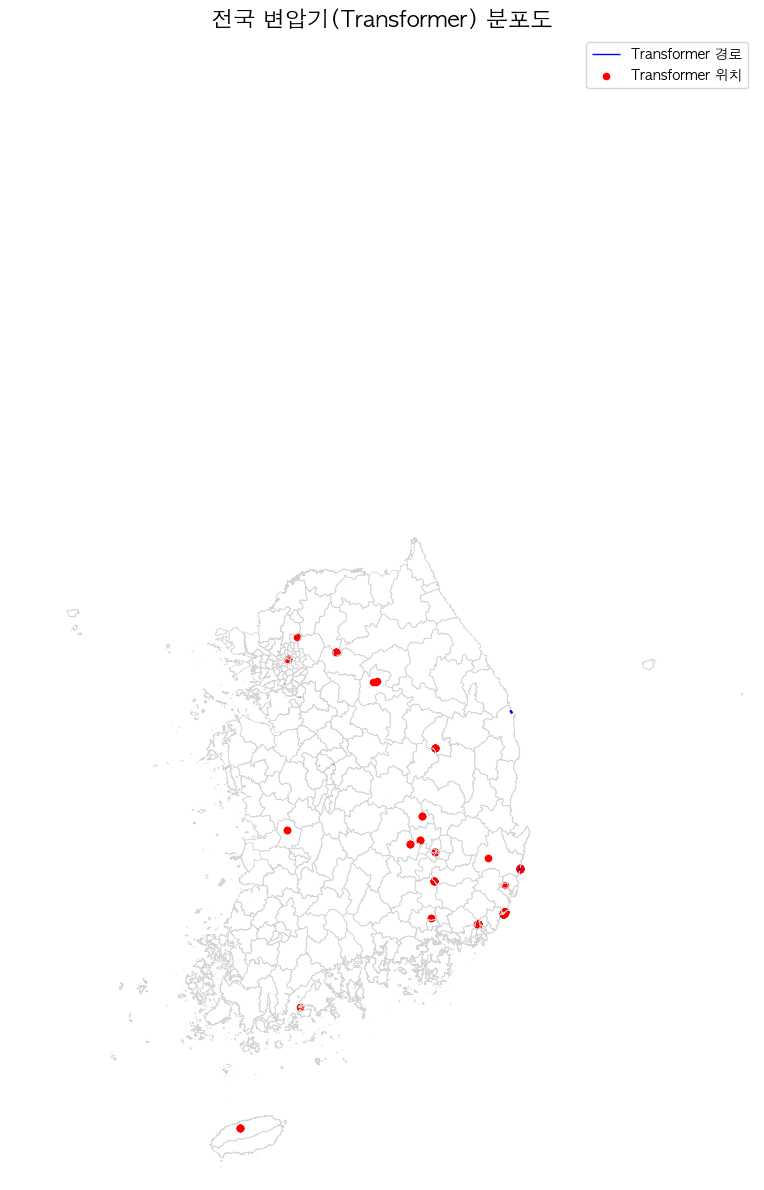

In [1]:
import pickle
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# ───────────────────────────────────────────────────────────────
# 1) 경로 설정
BASE_DIR      = Path("/Users/mousebook/Documents/university/연구실/solar/generator/v2/source")
TRANS_PATH    = BASE_DIR / "transformers.geojson"
GDF_DICT_PKL  = BASE_DIR / "gdf_dict_v2.pkl"
# ───────────────────────────────────────────────────────────────

# 2) 전국 행정구역 경계 로드
with open(GDF_DICT_PKL, "rb") as f:
    gdf_dict = pickle.load(f)
gdf_admin = gpd.GeoDataFrame(
    pd.concat(gdf_dict.values(), ignore_index=True),
    crs=list(gdf_dict.values())[0].crs
)

# 3) 변압기 데이터 로드
gdf_trans = gpd.read_file(TRANS_PATH)
# GeoJSON에 CRS 정보가 없으면 WGS84로 지정
if gdf_trans.crs is None:
    gdf_trans.set_crs(epsg=4326, inplace=True)

# 4) geometry 타입별로 분리
gdf_pts   = gdf_trans[gdf_trans.geometry.type == "Point"]
gdf_lines = gdf_trans[gdf_trans.geometry.type == "LineString"]
gdf_polys = gdf_trans[
    gdf_trans.geometry.type.isin(["Polygon", "MultiPolygon"])
]

# 5) 시각화
plt.rc("font", family="AppleGothic")
plt.rc("axes", unicode_minus=False)

fig, ax = plt.subplots(figsize=(10, 12))

# (1) 배경: 전국 경계
gdf_admin.boundary.plot(ax=ax, color="lightgray", linewidth=0.5)

# (2) Polygon: 주황 반투명
if not gdf_polys.empty:
    gdf_polys.plot(
        ax=ax,
        facecolor="orange",
        edgecolor="brown",
        alpha=0.4,
        label="Transformer 영역"
    )

# (3) LineString: 파랑 실선
if not gdf_lines.empty:
    gdf_lines.plot(
        ax=ax,
        color="blue",
        linewidth=1.0,
        label="Transformer 경로"
    )

# (4) Point: 빨강 점
if not gdf_pts.empty:
    gdf_pts.plot(
        ax=ax,
        color="red",
        marker="o",
        markersize=20,
        label="Transformer 위치"
    )

# (5) 한글 제목·범례·축 정리
ax.set_title("전국 변압기(Transformer) 분포도", fontsize=16)
ax.axis("off")
ax.legend()

# (6) 필요시 한반도 범위로 확대
ax.set_xlim(124, 132)
ax.set_ylim(33, 43)

plt.tight_layout()
plt.show()


# 송전선과 PV 사이의 거리 분포

한 지역데 대해서

/var/folders/yp/634kdqps0b7_jlvj3j_q0n8c0000gn/T/ipykernel_76003/3510689151.py:70: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  minx, miny, maxx, maxy = poly_gdf.unary_union.bounds
/var/folders/yp/634kdqps0b7_jlvj3j_q0n8c0000gn/T/ipykernel_76003/3510689151.py:77: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  if p.within(poly_gdf.unary_union):
/var/folders/yp/634kdqps0b7_jlvj3j_q0n8c0000gn/T/ipykernel_76003/3510689151.py:98: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/yp/634kdqps0b7_jlvj3j_q0n8c0000gn/T/ipykernel_76003/3510689151.py:98: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/yp/634kdqps0b7_jlvj3j_q0n8c0000gn/T/ipykernel_76003/3510689151.py:98: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from font(s) Deja

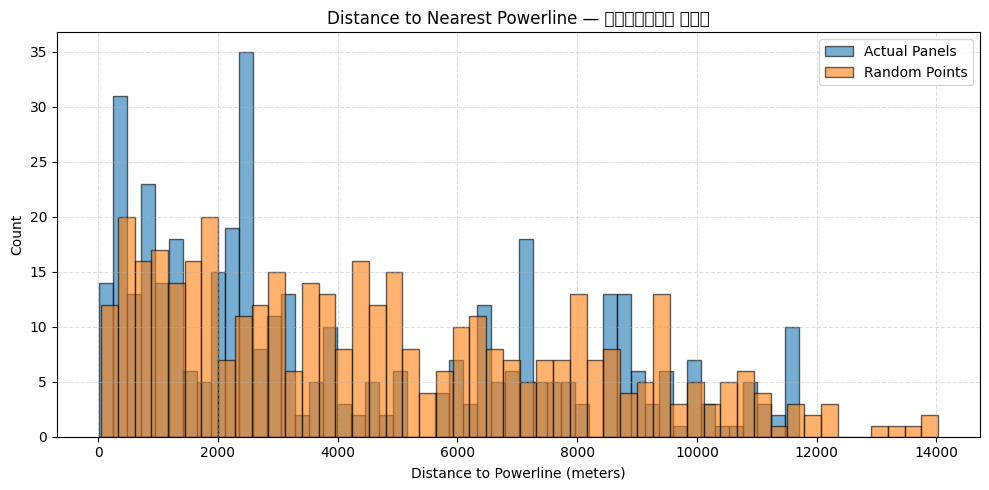

In [6]:
import pandas as pd
import geopandas as gpd
import numpy as np
from pathlib import Path
from shapely.geometry import Point, LineString, MultiLineString, Polygon, GeometryCollection
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
from utils import *

# —————————————————————————————
# 1) 관심 지역 데이터 로드
depth1 = "강원특별자치도"    # 예시: 1차 행정구역
depth2 = "인제군"    # 예시: 2차 행정구역
sub_df, region_code, gdf_region = filter_region_and_get_code_and_geom(depth1, depth2)

gdf_region = gdf_region.to_crs("EPSG:5179")

# 2) 실제 패널 GeoDataFrame 생성 (위도·경도 → Metric CRS)
panels = (
    gpd.GeoDataFrame(
        sub_df,
        geometry=gpd.points_from_xy(sub_df.x, sub_df.y),
        crs="EPSG:4326"
    )
    .to_crs("EPSG:5179")
)

# 3) 송전선 불러오기 & 모두 Metric CRS 로 변환
powerlines = (
    gpd.read_file(POWERLINE_GEOJSON)
       .to_crs("EPSG:5179")
       .geometry
)

# —————————————————————————————
# 4) KD-Tree 용 점 좌표 수집 (LineString, MultiLineString, Polygon 처리)
coords_list = []
for geom in powerlines:
    if isinstance(geom, LineString):
        coords_list.append(np.array(geom.coords))
    elif isinstance(geom, MultiLineString):
        for part in geom.geoms:
            coords_list.append(np.array(part.coords))
    elif isinstance(geom, Polygon):
        # 폴리곤 외곽선만 사용
        coords_list.append(np.array(geom.exterior.coords))
    elif isinstance(geom, GeometryCollection):
        for part in geom.geoms:
            if isinstance(part, LineString):
                coords_list.append(np.array(part.coords))
            elif isinstance(part, MultiLineString):
                for sub in part.geoms:
                    coords_list.append(np.array(sub.coords))
            elif isinstance(part, Polygon):
                coords_list.append(np.array(part.exterior.coords))
    else:
        # 그 외 지오메트리 타입은 무시
        continue

pline_pts = np.vstack(coords_list)
tree     = cKDTree(pline_pts)
# —————————————————————————————

# 5) 실제 패널 → 최근접 송전선 거리 계산
panel_coords  = np.column_stack((panels.geometry.x, panels.geometry.y))
dist_panel, _ = tree.query(panel_coords, k=1)

# 6) 지역 내부에 n_random 개의 랜덤 점 생성 함수
def sample_random_points_within(poly_gdf: gpd.GeoDataFrame, n_points: int) -> gpd.GeoSeries:
    minx, miny, maxx, maxy = poly_gdf.unary_union.bounds
    pts = []
    while len(pts) < n_points:
        xs = np.random.uniform(minx, maxx, n_points)
        ys = np.random.uniform(miny, maxy, n_points)
        for x, y in zip(xs, ys):
            p = Point(x, y)
            if p.within(poly_gdf.unary_union):
                pts.append(p)
                if len(pts) >= n_points:
                    break
    return gpd.GeoSeries(pts, crs=poly_gdf.crs)

# 7) 랜덤 샘플 점 & 거리 계산
n_random    = len(panels)                                    # 실제 패널 수와 동일하게
random_pts  = sample_random_points_within(gdf_region, n_random)
rand_arr    = np.column_stack((random_pts.x, random_pts.y))
dist_rand, _ = tree.query(rand_arr, k=1)

# 8) 히스토그램 비교 시각화
plt.figure(figsize=(10, 5))
plt.hist(dist_panel, bins=50, alpha=0.6, label="Actual Panels", edgecolor="black")
plt.hist(dist_rand,  bins=50, alpha=0.6, label="Random Points", edgecolor="black")
plt.title   (f"Distance to Nearest Powerline — {depth1} {depth2}")
plt.xlabel  ("Distance to Powerline (meters)")
plt.ylabel  ("Count")
plt.legend ()
plt.grid    (linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


PV가 존재하는 모든 지역에 대해서

/var/folders/yp/634kdqps0b7_jlvj3j_q0n8c0000gn/T/ipykernel_76003/1691514078.py:52: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  region_unions[(depth1, depth2)] = gdf_m.unary_union
/var/folders/yp/634kdqps0b7_jlvj3j_q0n8c0000gn/T/ipykernel_76003/1691514078.py:52: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  region_unions[(depth1, depth2)] = gdf_m.unary_union
/var/folders/yp/634kdqps0b7_jlvj3j_q0n8c0000gn/T/ipykernel_76003/1691514078.py:52: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  region_unions[(depth1, depth2)] = gdf_m.unary_union
/var/folders/yp/634kdqps0b7_jlvj3j_q0n8c0000gn/T/ipykernel_76003/1691514078.py:52: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  region_unions[(depth1, depth2)] = gdf_m.unary_union
/var/folders/yp/634kdqps0b7_jlvj3j_q0n8c0000gn/T

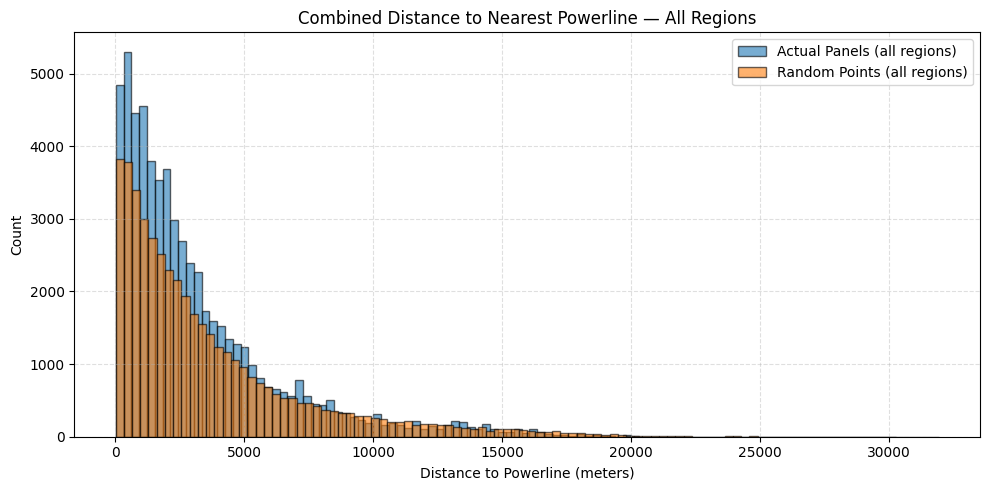

In [9]:
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString, MultiLineString, Polygon, GeometryCollection
from scipy.spatial import cKDTree
from utils import load_region_pairs, filter_region_and_get_code_and_geom, POWERLINE_GEOJSON

# —————————————————————————————
# 1) 송전선 KD-Tree 한 번만 구축
def build_powerline_kdtree(powerlines):
    coords_list = []
    for geom in powerlines:
        if isinstance(geom, LineString):
            coords_list.append(np.array(geom.coords))
        elif isinstance(geom, MultiLineString):
            for part in geom.geoms:
                coords_list.append(np.array(part.coords))
        elif isinstance(geom, Polygon):
            coords_list.append(np.array(geom.exterior.coords))
        elif isinstance(geom, GeometryCollection):
            for part in geom.geoms:
                if isinstance(part, LineString):
                    coords_list.append(np.array(part.coords))
                elif isinstance(part, MultiLineString):
                    for sub in part.geoms:
                        coords_list.append(np.array(sub.coords))
                elif isinstance(part, Polygon):
                    coords_list.append(np.array(part.exterior.coords))
    pline_pts = np.vstack(coords_list)
    return cKDTree(pline_pts)

powerlines = (
    gpd.read_file(POWERLINE_GEOJSON)
       .to_crs("EPSG:5179")
       .geometry
)
tree = build_powerline_kdtree(powerlines)

# 2) 모든 지역 데이터 미리 로드 & Metric CRS 변환
region_pairs = load_region_pairs()
region_unions = {}
panel_coords_by_region = {}

for depth1, depth2 in region_pairs:
    try:
        df, code, gdf = filter_region_and_get_code_and_geom(depth1, depth2)
    except Exception:
        continue

    # Metric CRS 변환
    gdf_m = gdf.to_crs("EPSG:5179")
    region_unions[(depth1, depth2)] = gdf_m.unary_union

    # 실제 패널 좌표
    panels = (
        gpd.GeoDataFrame(
            df,
            geometry=gpd.points_from_xy(df.x, df.y),
            crs="EPSG:4326"
        )
        .to_crs("EPSG:5179")
    )
    coords = np.column_stack((panels.geometry.x, panels.geometry.y))
    panel_coords_by_region[(depth1, depth2)] = coords

# 3) 실제 패널 거리 계산 (벡터화)
all_dist_panels = [
    tree.query(coords, k=1)[0]
    for coords in panel_coords_by_region.values()
]
all_dist_panels = np.concatenate(all_dist_panels)

# 4) 랜덤 포인트 배치 샘플링 & 거리 계산
all_dist_random = []

for (d1, d2), union_geom in region_unions.items():
    coords = panel_coords_by_region[(d1, d2)]
    n = coords.shape[0]

    # 충분히 크게 샘플링 후 필터링
    minx, miny, maxx, maxy = union_geom.bounds
    N = int(n * 1.5)
    xs = np.random.uniform(minx, maxx, N)
    ys = np.random.uniform(miny, maxy, N)
    pts = gpd.GeoSeries([Point(x, y) for x, y in zip(xs, ys)], crs="EPSG:5179")
    pts = pts[pts.within(union_geom)][:n]

    rand_coords = np.column_stack((pts.x, pts.y))
    all_dist_random.append(tree.query(rand_coords, k=1)[0])

all_dist_random = np.concatenate(all_dist_random)

# 5) 히스토그램 비교 시각화
plt.figure(figsize=(10, 5))
plt.hist(all_dist_panels, bins=100, alpha=0.6,
         label="Actual Panels (all regions)", edgecolor="black")
plt.hist(all_dist_random, bins=100, alpha=0.6,
         label="Random Points (all regions)", edgecolor="black")
plt.title("Combined Distance to Nearest Powerline — All Regions")
plt.xlabel("Distance to Powerline (meters)")
plt.ylabel("Count")
plt.legend()
plt.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


KS statistic = 0.0507, p-value = 1.3761e-58


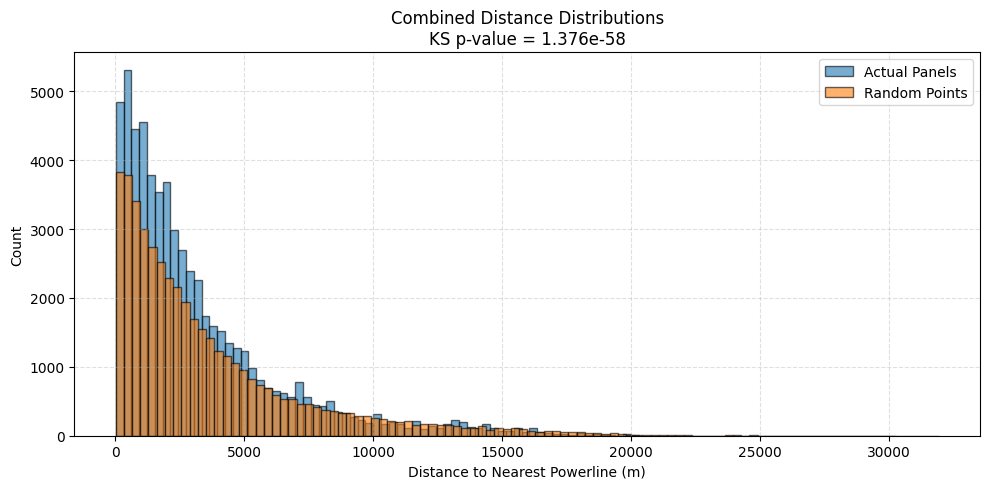

In [10]:
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt

# 1) KS 검정
stat, pvalue = ks_2samp(all_dist_panels, all_dist_random)
print(f"KS statistic = {stat:.4f}, p-value = {pvalue:.4e}")

# 2) 히스토그램 + p-value 표시
plt.figure(figsize=(10, 5))
plt.hist(all_dist_panels, bins=100, alpha=0.6,
         label="Actual Panels", edgecolor="black")
plt.hist(all_dist_random, bins=100, alpha=0.6,
         label="Random Points", edgecolor="black")
plt.title(f"Combined Distance Distributions\nKS p-value = {pvalue:.3e}")
plt.xlabel("Distance to Nearest Powerline (m)")
plt.ylabel("Count")
plt.legend()
plt.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
